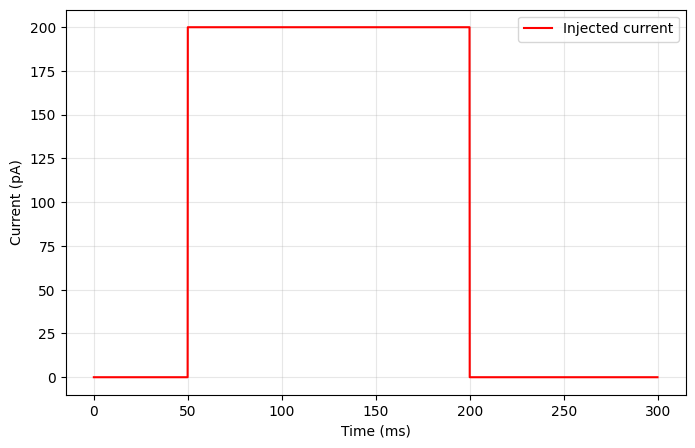

In [2]:
import numpy as np
import matplotlib.pyplot as plt

e_l = -65e-3          
v0 = -65e-3           
r_m = 100e6           
c_m = 200e-12         

dt = 1e-4
t_end = 0.3
time = np.arange(0, t_end, dt)

t_on = 0.05
t_off = 0.20
i0 = 200e-12

pulse_active = (time >= t_on) & (time < t_off)


current = np.zeros_like(time)
current[pulse_active] = i0

plt.figure(figsize=(8, 5))
plt.plot(time * 1e3, current * 1e12, color = 'red', label='Injected current')
plt.xlabel('Time (ms)')
plt.ylabel('Current (pA)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()



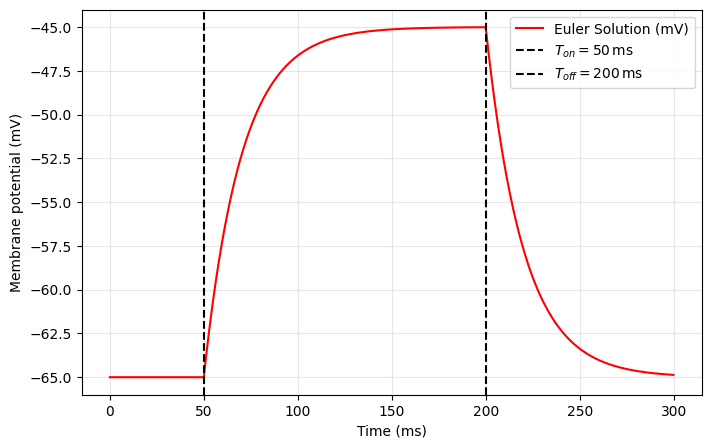

In [3]:
tau = r_m * c_m

v_euler = np.empty_like(time)
v_euler[0] = v0

for i in range(time.shape[0] - 1):
    dvdt = (-(v_euler[i] - e_l) / tau + current[i] / c_m)
    v_euler[i+1] = v_euler[i] + dt * dvdt


plt.figure(figsize=(8, 5))
plt.plot(time * 1e3, v_euler * 1e3, color = 'red', label='Euler Solution (mV)')

plt.axvline(t_on * 1e3, linestyle = '--', color = 'black', label = fr'$T_{{on}} = {t_on * 1e3:.0f}\, \mathrm{{ms}} $')
plt.axvline(t_off * 1e3, linestyle = '--', color = 'black', label = fr'$T_{{off}} = {t_off * 1e3:.0f}\, \mathrm{{ms}} $')

plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()


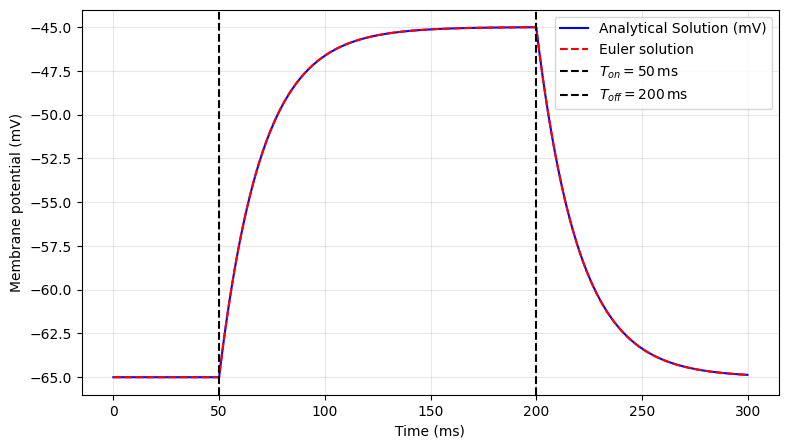

Maximum error (mV): 0.01843238890546217


In [4]:
v_inf = i0 * r_m + e_l

before = time < t_on
during = (time >= t_on) & (time < t_off)
after = time >= t_off

v_on = e_l + (v0 - e_l) * np.exp((-t_on)/tau)
v_off = v_inf + (v_on - v_inf) * np.exp((-(t_off - t_on))/tau)

v_analytical_before = e_l + (v0 - e_l) * np.exp((-time[before])/tau)
v_analytical_during = v_inf + (v_on - v_inf) * np.exp(-(time[during] - t_on)/tau)
v_analytical_after = e_l + (v_off - e_l) * np.exp(-(time[after] - t_off)/tau)

v_analytical = np.empty_like(time)
v_analytical[before] = v_analytical_before
v_analytical[during] = v_analytical_during
v_analytical[after] = v_analytical_after

plt.figure(figsize=(9, 5))
plt.plot(time * 1e3, v_analytical * 1e3, color = 'blue', label='Analytical Solution (mV)')
plt.plot(time * 1e3, v_euler * 1e3, '--', color='red', label='Euler solution')
plt.axvline(t_on * 1e3, linestyle = '--', color = 'black', label = fr'$T_{{on}} = {t_on * 1e3:.0f}\, \mathrm{{ms}} $')
plt.axvline(t_off * 1e3, linestyle = '--', color = 'black', label = fr'$T_{{off}} = {t_off * 1e3:.0f}\, \mathrm{{ms}} $')

plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()


print("Maximum error (mV):",
      np.max(np.abs(v_euler - v_analytical)) * 1e3)



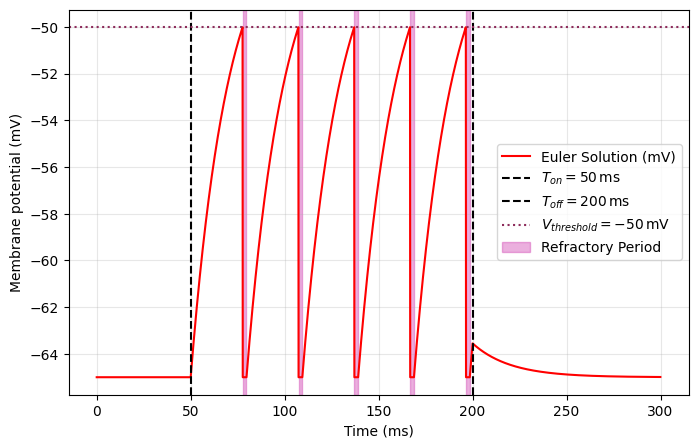

Analytical frequency: 33.6407 Hz
Euler frequency:      33.6700 Hz
Spike times (ms): [ 77.7 107.4 137.1 166.8 196.5]


In [5]:
v_reset = -65 * 1e-3
v_threshold = -50 * 1e-3
t_refractory = 2 * 1e-3 

v = np.empty_like(time)
v[0] = v0

spike_times = []
refractory_until = 0
for i in range(time.shape[0] - 1):

    if time[i] < refractory_until:
        v[i+1] = v[i]
        continue

    dvdt = (-(v[i] - e_l) / tau + current[i] / c_m)
    v[i+1] = v[i] + dt * dvdt

    if v[i+1] >= v_threshold:
        v[i+1] = v_reset
        spike_times.append(time[i+1])
        refractory_until = time[i+1] + t_refractory

spike_times = np.array(spike_times)

plt.figure(figsize=(8, 5))
plt.plot(time * 1e3, v * 1e3, color = 'red', label='Euler Solution (mV)')

plt.axvline(t_on * 1e3, linestyle = '--', color = 'black', label = fr'$T_{{on}} = {t_on * 1e3:.0f}\, \mathrm{{ms}} $')
plt.axvline(t_off * 1e3, linestyle = '--', color = 'black', label = fr'$T_{{off}} = {t_off * 1e3:.0f}\, \mathrm{{ms}} $')
plt.axhline(v_threshold * 1e3, linestyle = ':', color = "#8D2C5B", label = fr'$V_{{threshold}} = {v_threshold * 1e3:.0f}\, \mathrm{{mV}} $')

for k, spike_time in enumerate(spike_times):
    label = 'Refractory Period' if k == 0 else None
    plt.axvspan(spike_time * 1e3, (spike_time + t_refractory) * 1e3, color = "#CE37AD", alpha = 0.4, label = label)


plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()


I_rh = (v_threshold - e_l)/r_m
if i0 > I_rh:
    T_charge = tau * np.log((v_reset - v_inf)/(v_threshold - v_inf))
    T_analytic = t_refractory + T_charge
    F_analytic = 1/T_analytic
else:
    F_analytic = 0


if i0 <= I_rh:
    F_euler = 0.0
elif spike_times.size >= 2:
    F_euler = 1 / np.mean(np.diff(spike_times))
else:
    F_euler = np.nan

print(f"Analytical frequency: {F_analytic:.4f} Hz")
print(f"Euler frequency:      {F_euler:.4f} Hz")
print("Spike times (ms):", spike_times * 1e3)

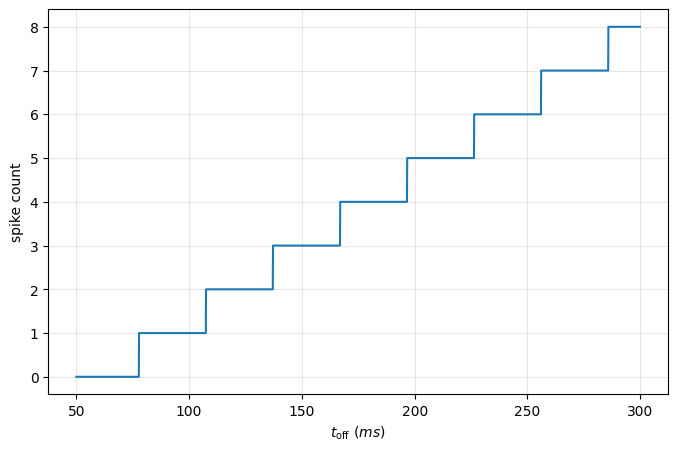

In [6]:
t_off_variable = np.arange(t_on, t_end, dt)
dif = t_off_variable - t_on
skip = dif - T_charge   # skipping first spike 
mask = skip >= 0

spike_count = np.zeros_like(dif)
spike_count[mask] = 1 + skip[mask]//T_analytic


plt.figure(figsize=(8, 5))
plt.plot(t_off_variable * 1e3, spike_count)
plt.xlabel(fr'$t_\mathrm{{off}} \,\, (ms)$')
plt.ylabel('spike count')
plt.grid(alpha = 0.3)
plt.show()